<a href="https://colab.research.google.com/github/keksenia/cstati-event-analytics/blob/main/notebooks/04_deep_dive_events.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from pathlib import Path

Path("/content/manual").mkdir(parents=True, exist_ok=True)
Path("/content/data/interim_private/identity").mkdir(parents=True, exist_ok=True)
Path("/content/data/processed_public").mkdir(parents=True, exist_ok=True)
Path("/content/docs/figures").mkdir(parents=True, exist_ok=True)

# 04 — Deep Dive Events

Цель ноутбука — глубоко разобрать ключевые мероприятия cstati с продуктовой точки зрения.

В этом ноутбуке мы:

- выбираем 6 событий для deep dive;
- сравниваем их по acquisition, retention и data quality;
- смотрим, какие события приводят новых участников;
- какие события возвращают людей;
- какие event journeys возникают после участия;
- формируем actionable recommendations для развития event portfolio.

Фокус: не просто описать события, а понять, какую продуктовую роль они играют в росте и удержании комьюнити.



In [11]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 150)

PROJECT_ROOT = Path("/content")

MANUAL_DIR = PROJECT_ROOT / "manual"
IDENTITY_DIR = PROJECT_ROOT / "data" / "interim_private" / "identity"
PROCESSED_PUBLIC_DIR = PROJECT_ROOT / "data" / "processed_public"
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_PUBLIC_DIR.mkdir(parents=True, exist_ok=True)

print("MANUAL_DIR:", MANUAL_DIR)
print("IDENTITY_DIR:", IDENTITY_DIR)
print("PROCESSED_PUBLIC_DIR:", PROCESSED_PUBLIC_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


MANUAL_DIR: /content/manual
IDENTITY_DIR: /content/data/interim_private/identity
PROCESSED_PUBLIC_DIR: /content/data/processed_public
FIGURES_DIR: /content/docs/figures


In [12]:
def load_processed_table(name: str) -> pd.DataFrame:
    parquet_path = PROCESSED_PUBLIC_DIR / f"{name}.parquet"
    csv_path = PROCESSED_PUBLIC_DIR / f"{name}.csv"

    if parquet_path.exists():
        return pd.read_parquet(parquet_path)

    if csv_path.exists():
        return pd.read_csv(csv_path)

    raise FileNotFoundError(
        f"Не найден {name}.parquet или {name}.csv в {PROCESSED_PUBLIC_DIR}. "
        "Сначала запусти 03_portfolio_overview.ipynb до ячейки сохранения public aggregate marts."
    )


event_metrics = load_processed_table("metrics_event_level")
family_metrics = load_processed_table("metrics_family_level")
event_scorecard = load_processed_table("event_scorecard")
event_transitions = load_processed_table("event_transitions")
family_transitions = load_processed_table("family_transitions")

identity_path = IDENTITY_DIR / "identity_records_private.csv"
metadata_path = MANUAL_DIR / "event_metadata.csv"

if not identity_path.exists():
    raise FileNotFoundError("Не найден identity_records_private.csv. Нужно загрузить output из 02-го ноутбука.")

if not metadata_path.exists():
    raise FileNotFoundError("Не найден event_metadata.csv. Нужно загрузить manual/event_metadata.csv.")

identity_records_df = pd.read_csv(identity_path, dtype=str)
event_metadata = pd.read_csv(metadata_path, dtype=str)

print("event_metrics:", event_metrics.shape)
print("family_metrics:", family_metrics.shape)
print("event_scorecard:", event_scorecard.shape)
print("event_transitions:", event_transitions.shape)
print("identity_records_df:", identity_records_df.shape)
print("event_metadata:", event_metadata.shape)


event_metrics: (18, 29)
family_metrics: (13, 12)
event_scorecard: (18, 15)
event_transitions: (64, 3)
identity_records_df: (11290, 27)
event_metadata: (18, 13)


In [13]:
def to_bool_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


for col in ["is_auxiliary_source", "identity_conflict_flag"]:
    if col in identity_records_df.columns:
        identity_records_df[col] = to_bool_series(identity_records_df[col])


event_metadata["event_year"] = pd.to_numeric(event_metadata["event_year"], errors="coerce")

season_order_map = {
    "winter": 1,
    "spring": 2,
    "summer": 3,
    "autumn": 4,
    "fall": 4,
    "unknown": 9,
}

event_metadata["event_season_order"] = (
    event_metadata["event_season"]
    .fillna("unknown")
    .str.lower()
    .map(season_order_map)
    .fillna(9)
)

event_metadata["metadata_order"] = np.arange(len(event_metadata))

event_metadata["event_order"] = (
    event_metadata["event_year"].fillna(9999) * 100
    + event_metadata["event_season_order"]
    + event_metadata["metadata_order"] / 1000
)

event_metadata_short = event_metadata.rename(columns={"event_id": "canonical_event_id"})

clean_identity_df = identity_records_df[
    (identity_records_df["is_auxiliary_source"] == False)
    & (identity_records_df["identity_conflict_flag"] == False)
    & (identity_records_df["identity_confidence"].isin(["high", "medium"]))
    & (identity_records_df["participant_hash_private"].notna())
].copy()

clean_identity_df = clean_identity_df.merge(
    event_metadata_short,
    on="canonical_event_id",
    how="left",
)

event_participation_clean = (
    clean_identity_df
    .drop_duplicates(["canonical_event_id", "participant_hash_private"])
    .copy()
)

clean_sequence = event_participation_clean[
    [
        "participant_hash_private",
        "canonical_event_id",
        "event_name",
        "event_family",
        "event_year",
        "event_order",
        "strategic_role",
    ]
].dropna(subset=["participant_hash_private", "canonical_event_id", "event_order"]).copy()

clean_sequence = clean_sequence.sort_values(
    ["participant_hash_private", "event_order", "canonical_event_id"]
)

clean_sequence["participant_event_rank"] = (
    clean_sequence
    .groupby("participant_hash_private")
    .cumcount()
    + 1
)

clean_sequence["max_event_rank"] = (
    clean_sequence
    .groupby("participant_hash_private")["participant_event_rank"]
    .transform("max")
)

clean_sequence["is_first_event"] = clean_sequence["participant_event_rank"] == 1
clean_sequence["has_future_event"] = clean_sequence["participant_event_rank"] < clean_sequence["max_event_rank"]

print("clean_identity_df:", clean_identity_df.shape)
print("event_participation_clean:", event_participation_clean.shape)
print("clean_sequence:", clean_sequence.shape)

display(clean_sequence.head())


clean_identity_df: (2933, 42)
event_participation_clean: (2853, 42)
clean_sequence: (2853, 11)


,participant_hash_private,canonical_event_id,event_name,event_family,event_year,event_order,strategic_role,participant_event_rank,max_event_rank,is_first_event,has_future_event
1581,0014ef7d6070eeff00fe659a30b71b56cdb6aead4cbdd62ec2706a9b1d20b10d,posvyat_2023,Посвят'23,Посвят,2023,202304.000,acquisition,1,1,True,False
2001,0039114fa343353daf5c750c1ce07a65279bf694c6291e4b45f4d05203ddaea4,posvyat_2025,Посвят'25,Посвят,2025,202504.012,acquisition,1,1,True,False
223,003d3800ce2aa9f03e2a971eb9cc8413791c831161ec28e0d61c065d6a306025,csfest_2025,CSFEST'25,CSFEST,2025,202502.014,reach/community,1,1,True,False
1094,009ccf5d665996591d6df17c52aa486a5d09dda88e1eb90f8a6c2cab2f30ef13,neyrorave_2024,Нейрорейв,Нейрорейв,2024,202402.007,acquisition/reach,1,1,True,False
1287,00a750f3d2ab135575c2df61ed820fcdae14317cce1396417e9f98c728ce2e43,neyrorave_2024,Нейрорейв,Нейрорейв,2024,202402.007,acquisition/reach,1,1,True,False


In [14]:
DEEP_DIVE_EVENT_IDS = [
    "neyrorave_2024",
    "posvyat_2025",
    "csfest_2025",
    "pohod_2025",
    "antiposvyat_2025",
    "nastolki_2024",
]

deep_dive_events = event_metrics[
    event_metrics["canonical_event_id"].isin(DEEP_DIVE_EVENT_IDS)
].copy()

deep_dive_events = deep_dive_events.sort_values("clean_participants", ascending=False)

display(deep_dive_events[
    [
        "canonical_event_id",
        "event_name",
        "event_family",
        "event_year",
        "strategic_role",
        "clean_participants",
        "new_participants",
        "repeat_participants",
        "new_share",
        "repeat_share",
        "clean_coverage_share",
    ]
])


,canonical_event_id,event_name,event_family,event_year,strategic_role,clean_participants,new_participants,repeat_participants,new_share,repeat_share,clean_coverage_share
4,neyrorave_2024,Нейрорейв,Нейрорейв,2024,acquisition/reach,728,728,0,1.000,0.000,0.899876
15,posvyat_2025,Посвят'25,Посвят,2025,acquisition,400,397,3,0.992,0.008,0.959233
12,csfest_2025,CSFEST'25,CSFEST,2025,reach/community,259,214,45,0.826,0.174,0.727528
13,pohod_2025,Поход'25,Поход,2025,retention/community,219,129,90,0.589,0.411,0.752577
16,antiposvyat_2025,Антипосвят'25,Антипосвят,2025,retention/community,113,66,47,0.584,0.416,0.513636
10,nastolki_2024,Настолки'24,Настолки,2024,engagement,47,23,24,0.489,0.511,0.522222


In [15]:
future_event_metrics = (
    clean_sequence
    .groupby("canonical_event_id", dropna=False)
    .agg(
        clean_participants=("participant_hash_private", "nunique"),
        participants_with_future_event=("has_future_event", "sum"),
    )
    .reset_index()
)

future_event_metrics["future_event_rate"] = (
    future_event_metrics["participants_with_future_event"]
    / future_event_metrics["clean_participants"]
).round(3)

deep_dive_summary = (
    deep_dive_events
    .merge(
        future_event_metrics[
            [
                "canonical_event_id",
                "participants_with_future_event",
                "future_event_rate",
            ]
        ],
        on="canonical_event_id",
        how="left",
    )
)

deep_dive_summary["participants_with_future_event"] = (
    deep_dive_summary["participants_with_future_event"].fillna(0).astype(int)
)

deep_dive_summary["future_event_rate"] = deep_dive_summary["future_event_rate"].fillna(0)

display(deep_dive_summary[
    [
        "event_name",
        "event_family",
        "strategic_role",
        "clean_participants",
        "new_share",
        "repeat_share",
        "future_event_rate",
        "clean_coverage_share",
    ]
].sort_values("clean_participants", ascending=False))


,event_name,event_family,strategic_role,clean_participants,new_share,repeat_share,future_event_rate,clean_coverage_share
0,Нейрорейв,Нейрорейв,acquisition/reach,728,1.000,0.000,0.001,0.899876
1,Посвят'25,Посвят,acquisition,400,0.992,0.008,0.030,0.959233
2,CSFEST'25,CSFEST,reach/community,259,0.826,0.174,0.147,0.727528
3,Поход'25,Поход,retention/community,219,0.589,0.411,0.050,0.752577
4,Антипосвят'25,Антипосвят,retention/community,113,0.584,0.416,0.000,0.513636
5,Настолки'24,Настолки,engagement,47,0.489,0.511,0.255,0.522222


In [16]:
def classify_event_role(row):
    clean_participants = row.get("clean_participants", 0)
    new_share = row.get("new_share", 0)
    repeat_share = row.get("repeat_share", 0)
    future_event_rate = row.get("future_event_rate", 0)

    if clean_participants >= 250 and new_share >= 0.85:
        return "acquisition engine"

    if repeat_share >= 0.35:
        return "retention/community engine"

    if future_event_rate >= 0.15 and clean_participants >= 100:
        return "activation bridge"

    if clean_participants >= 200:
        return "reach event"

    return "niche/community event"


def classify_data_quality(row):
    coverage = row.get("clean_coverage_share", np.nan)

    if pd.isna(coverage):
        return "not enough clean data"

    if coverage >= 0.75:
        return "good"

    if coverage >= 0.5:
        return "medium"

    return "risky"


deep_dive_summary["product_role"] = deep_dive_summary.apply(classify_event_role, axis=1)
deep_dive_summary["data_quality_status"] = deep_dive_summary.apply(classify_data_quality, axis=1)

display(deep_dive_summary[
    [
        "event_name",
        "event_family",
        "product_role",
        "data_quality_status",
        "clean_participants",
        "new_share",
        "repeat_share",
        "future_event_rate",
        "clean_coverage_share",
    ]
].sort_values("clean_participants", ascending=False))


,event_name,event_family,product_role,data_quality_status,clean_participants,new_share,repeat_share,future_event_rate,clean_coverage_share
0,Нейрорейв,Нейрорейв,acquisition engine,good,728,1.000,0.000,0.001,0.899876
1,Посвят'25,Посвят,acquisition engine,good,400,0.992,0.008,0.030,0.959233
2,CSFEST'25,CSFEST,reach event,medium,259,0.826,0.174,0.147,0.727528
3,Поход'25,Поход,retention/community engine,good,219,0.589,0.411,0.050,0.752577
4,Антипосвят'25,Антипосвят,retention/community engine,medium,113,0.584,0.416,0.000,0.513636
5,Настолки'24,Настолки,retention/community engine,medium,47,0.489,0.511,0.255,0.522222


In [17]:
journey_df = clean_sequence.sort_values(
    ["participant_hash_private", "event_order"]
).copy()

journey_df["next_event_name"] = (
    journey_df
    .groupby("participant_hash_private")["event_name"]
    .shift(-1)
)

journey_df["next_event_family"] = (
    journey_df
    .groupby("participant_hash_private")["event_family"]
    .shift(-1)
)

deep_dive_next_events = (
    journey_df[
        journey_df["canonical_event_id"].isin(DEEP_DIVE_EVENT_IDS)
        & journey_df["next_event_name"].notna()
    ]
    .groupby(["event_name", "next_event_name"], dropna=False)
    .agg(
        participants=("participant_hash_private", "nunique")
    )
    .reset_index()
    .sort_values(["event_name", "participants"], ascending=[True, False])
)

display(deep_dive_next_events)


,event_name,next_event_name,participants
2,CSFEST'25,Поход'25,27
0,CSFEST'25,Антипосвят'25,8
1,CSFEST'25,Посвят'25,2
3,CSFEST'25,Экватор'25,1
4,Настолки'24,CSFEST'25,7
6,Настолки'24,Поход'25,3
5,Настолки'24,Антипосвят'25,2
7,Нейрорейв,CSFEST'25,1
8,Посвят'25,Антипосвят'25,12
9,Поход'25,Антипосвят'25,9


In [18]:
journey_df["previous_event_name"] = (
    journey_df
    .groupby("participant_hash_private")["event_name"]
    .shift(1)
)

journey_df["previous_event_family"] = (
    journey_df
    .groupby("participant_hash_private")["event_family"]
    .shift(1)
)

deep_dive_previous_events = (
    journey_df[
        journey_df["canonical_event_id"].isin(DEEP_DIVE_EVENT_IDS)
        & journey_df["previous_event_name"].notna()
    ]
    .groupby(["previous_event_name", "event_name"], dropna=False)
    .agg(
        participants=("participant_hash_private", "nunique")
    )
    .reset_index()
    .sort_values(["event_name", "participants"], ascending=[True, False])
)

display(deep_dive_previous_events)


,previous_event_name,event_name,participants
23,Посвят'23,CSFEST'25,10
29,Поход'24,CSFEST'25,9
19,Настолки'24,CSFEST'25,7
10,GLANZ,CSFEST'25,6
17,ЗВ'25,CSFEST'25,6
0,ANNIVERSARY'24,CSFEST'25,3
3,Ballmer Peak'24,CSFEST'25,1
14,Антипосвят'23,CSFEST'25,1
22,Нейрорейв,CSFEST'25,1
33,Экватор'24,CSFEST'25,1


In [19]:
def build_event_recommendation(row):
    event_name = row["event_name"]
    product_role = row["product_role"]
    new_share = row["new_share"]
    repeat_share = row["repeat_share"]
    future_event_rate = row["future_event_rate"]
    clean_coverage_share = row["clean_coverage_share"]

    recommendations = []

    if product_role == "acquisition engine":
        recommendations.append(
            "Использовать событие как верх воронки: заранее готовить follow-up коммуникацию и приглашение на следующее community-событие."
        )

    if new_share >= 0.85 and future_event_rate < 0.1:
        recommendations.append(
            "Добавить post-event activation: подборку следующих событий, Telegram-канал/чат, персональное приглашение на ближайший формат."
        )

    if repeat_share >= 0.35:
        recommendations.append(
            "Масштабировать retention-механики события: сохранять формат, усиливать комьюнити-ритуалы, приглашать участников прошлых событий."
        )

    if future_event_rate >= 0.15:
        recommendations.append(
            "Событие работает как bridge к следующим активностям: стоит строить journey-коммуникации вокруг него."
        )

    if pd.notna(clean_coverage_share) and clean_coverage_share < 0.6:
        recommendations.append(
            "Улучшить качество регистрационной формы: сделать Telegram/почту обязательными или стандартизировать поля."
        )

    if not recommendations:
        recommendations.append(
            "Использовать как поддерживающий формат портфеля и продолжить сбор данных для оценки роли в retention."
        )

    return " ".join(recommendations)


deep_dive_recommendations = deep_dive_summary[
    [
        "canonical_event_id",
        "event_name",
        "event_family",
        "product_role",
        "data_quality_status",
        "clean_participants",
        "new_share",
        "repeat_share",
        "future_event_rate",
        "clean_coverage_share",
    ]
].copy()

deep_dive_recommendations["recommendation"] = deep_dive_recommendations.apply(
    build_event_recommendation,
    axis=1,
)

display(deep_dive_recommendations.sort_values("clean_participants", ascending=False))



,canonical_event_id,event_name,event_family,product_role,data_quality_status,clean_participants,new_share,repeat_share,future_event_rate,clean_coverage_share,recommendation
0,neyrorave_2024,Нейрорейв,Нейрорейв,acquisition engine,good,728,1.000,0.000,0.001,0.899876,Использовать событие как верх воронки: заранее готовить follow-up коммуникацию и приглашение на следующее community-событие. Добавить post-event a...
1,posvyat_2025,Посвят'25,Посвят,acquisition engine,good,400,0.992,0.008,0.030,0.959233,Использовать событие как верх воронки: заранее готовить follow-up коммуникацию и приглашение на следующее community-событие. Добавить post-event a...
2,csfest_2025,CSFEST'25,CSFEST,reach event,medium,259,0.826,0.174,0.147,0.727528,Использовать как поддерживающий формат портфеля и продолжить сбор данных для оценки роли в retention.
3,pohod_2025,Поход'25,Поход,retention/community engine,good,219,0.589,0.411,0.050,0.752577,"Масштабировать retention-механики события: сохранять формат, усиливать комьюнити-ритуалы, приглашать участников прошлых событий."
4,antiposvyat_2025,Антипосвят'25,Антипосвят,retention/community engine,medium,113,0.584,0.416,0.000,0.513636,"Масштабировать retention-механики события: сохранять формат, усиливать комьюнити-ритуалы, приглашать участников прошлых событий. Улучшить качество..."
5,nastolki_2024,Настолки'24,Настолки,retention/community engine,medium,47,0.489,0.511,0.255,0.522222,"Масштабировать retention-механики события: сохранять формат, усиливать комьюнити-ритуалы, приглашать участников прошлых событий. Событие работает ..."


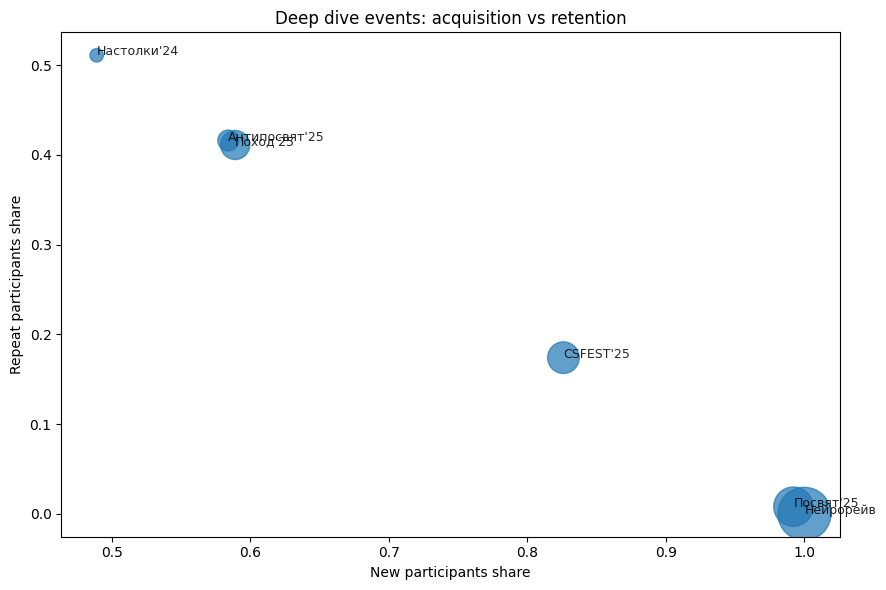

saved: /content/docs/figures/deep_dive_acquisition_vs_retention.png


In [20]:
plot_df = deep_dive_summary.copy()

fig, ax = plt.subplots(figsize=(9, 6))

sizes = plot_df["clean_participants"].clip(lower=20) * 2

ax.scatter(
    plot_df["new_share"],
    plot_df["repeat_share"],
    s=sizes,
    alpha=0.7,
)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["event_name"],
        (row["new_share"], row["repeat_share"]),
        fontsize=9,
        alpha=0.85,
    )

ax.set_title("Deep dive events: acquisition vs retention")
ax.set_xlabel("New participants share")
ax.set_ylabel("Repeat participants share")

plt.tight_layout()

fig_path = FIGURES_DIR / "deep_dive_acquisition_vs_retention.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", fig_path)


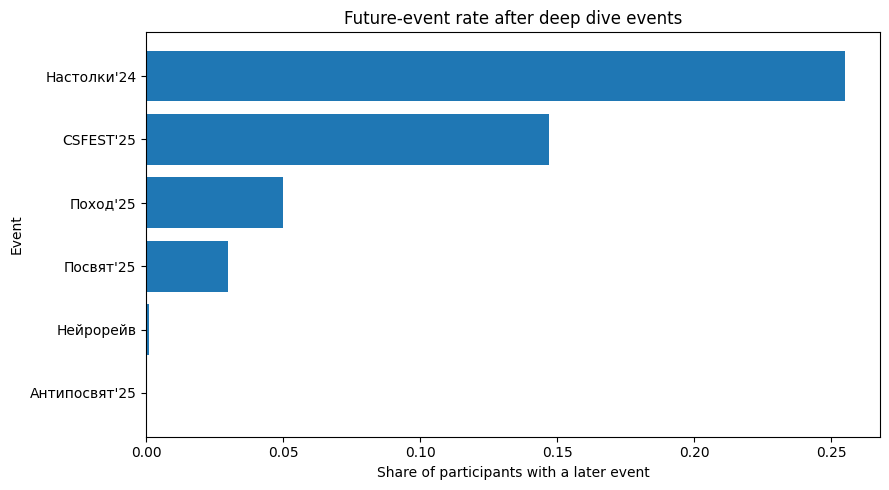

saved: /content/docs/figures/deep_dive_future_event_rate.png


In [21]:
plot_df = deep_dive_summary.sort_values("future_event_rate", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["event_name"], plot_df["future_event_rate"])

ax.set_title("Future-event rate after deep dive events")
ax.set_xlabel("Share of participants with a later event")
ax.set_ylabel("Event")

plt.tight_layout()

fig_path = FIGURES_DIR / "deep_dive_future_event_rate.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", fig_path)


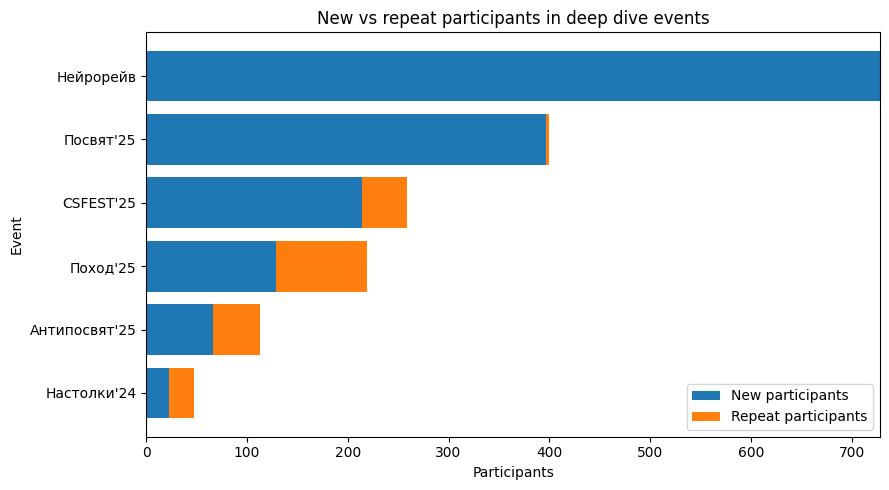

saved: /content/docs/figures/deep_dive_new_vs_repeat.png


In [22]:
plot_df = deep_dive_summary.sort_values("clean_participants", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["event_name"], plot_df["new_participants"], label="New participants")
ax.barh(
    plot_df["event_name"],
    plot_df["repeat_participants"],
    left=plot_df["new_participants"],
    label="Repeat participants",
)

ax.set_title("New vs repeat participants in deep dive events")
ax.set_xlabel("Participants")
ax.set_ylabel("Event")
ax.legend()

plt.tight_layout()

fig_path = FIGURES_DIR / "deep_dive_new_vs_repeat.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved:", fig_path)


In [23]:
deep_dive_outputs = {
    "deep_dive_summary": deep_dive_summary,
    "deep_dive_next_events": deep_dive_next_events,
    "deep_dive_previous_events": deep_dive_previous_events,
    "deep_dive_recommendations": deep_dive_recommendations,
}

for name, df in deep_dive_outputs.items():
    output_path = PROCESSED_PUBLIC_DIR / f"{name}.parquet"

    try:
        df.to_parquet(output_path, index=False)
        print("saved:", output_path)
    except Exception as e:
        fallback_path = PROCESSED_PUBLIC_DIR / f"{name}.csv"
        df.to_csv(fallback_path, index=False)
        print("parquet failed, saved csv instead:", fallback_path, "|", e)


saved: /content/data/processed_public/deep_dive_summary.parquet
saved: /content/data/processed_public/deep_dive_next_events.parquet
saved: /content/data/processed_public/deep_dive_previous_events.parquet
saved: /content/data/processed_public/deep_dive_recommendations.parquet


In [24]:
print("=== DEEP DIVE SUMMARY ===")
display(deep_dive_summary[
    [
        "event_name",
        "event_family",
        "product_role",
        "data_quality_status",
        "clean_participants",
        "new_participants",
        "repeat_participants",
        "new_share",
        "repeat_share",
        "future_event_rate",
        "clean_coverage_share",
    ]
].sort_values("clean_participants", ascending=False))

print("\n=== NEXT EVENTS ===")
display(deep_dive_next_events.head(20))

print("\n=== PREVIOUS EVENTS ===")
display(deep_dive_previous_events.head(20))

print("\n=== RECOMMENDATIONS ===")
display(deep_dive_recommendations[
    [
        "event_name",
        "product_role",
        "data_quality_status",
        "recommendation",
    ]
])


=== DEEP DIVE SUMMARY ===


,event_name,event_family,product_role,data_quality_status,clean_participants,new_participants,repeat_participants,new_share,repeat_share,future_event_rate,clean_coverage_share
0,Нейрорейв,Нейрорейв,acquisition engine,good,728,728,0,1.000,0.000,0.001,0.899876
1,Посвят'25,Посвят,acquisition engine,good,400,397,3,0.992,0.008,0.030,0.959233
2,CSFEST'25,CSFEST,reach event,medium,259,214,45,0.826,0.174,0.147,0.727528
3,Поход'25,Поход,retention/community engine,good,219,129,90,0.589,0.411,0.050,0.752577
4,Антипосвят'25,Антипосвят,retention/community engine,medium,113,66,47,0.584,0.416,0.000,0.513636
5,Настолки'24,Настолки,retention/community engine,medium,47,23,24,0.489,0.511,0.255,0.522222



=== NEXT EVENTS ===


,event_name,next_event_name,participants
2,CSFEST'25,Поход'25,27
0,CSFEST'25,Антипосвят'25,8
1,CSFEST'25,Посвят'25,2
3,CSFEST'25,Экватор'25,1
4,Настолки'24,CSFEST'25,7
6,Настолки'24,Поход'25,3
5,Настолки'24,Антипосвят'25,2
7,Нейрорейв,CSFEST'25,1
8,Посвят'25,Антипосвят'25,12
9,Поход'25,Антипосвят'25,9



=== PREVIOUS EVENTS ===


,previous_event_name,event_name,participants
23,Посвят'23,CSFEST'25,10
29,Поход'24,CSFEST'25,9
19,Настолки'24,CSFEST'25,7
10,GLANZ,CSFEST'25,6
17,ЗВ'25,CSFEST'25,6
0,ANNIVERSARY'24,CSFEST'25,3
3,Ballmer Peak'24,CSFEST'25,1
14,Антипосвят'23,CSFEST'25,1
22,Нейрорейв,CSFEST'25,1
33,Экватор'24,CSFEST'25,1



=== RECOMMENDATIONS ===


,event_name,product_role,data_quality_status,recommendation
0,Нейрорейв,acquisition engine,good,Использовать событие как верх воронки: заранее готовить follow-up коммуникацию и приглашение на следующее community-событие. Добавить post-event a...
1,Посвят'25,acquisition engine,good,Использовать событие как верх воронки: заранее готовить follow-up коммуникацию и приглашение на следующее community-событие. Добавить post-event a...
2,CSFEST'25,reach event,medium,Использовать как поддерживающий формат портфеля и продолжить сбор данных для оценки роли в retention.
3,Поход'25,retention/community engine,good,"Масштабировать retention-механики события: сохранять формат, усиливать комьюнити-ритуалы, приглашать участников прошлых событий."
4,Антипосвят'25,retention/community engine,medium,"Масштабировать retention-механики события: сохранять формат, усиливать комьюнити-ритуалы, приглашать участников прошлых событий. Улучшить качество..."
5,Настолки'24,retention/community engine,medium,"Масштабировать retention-механики события: сохранять формат, усиливать комьюнити-ритуалы, приглашать участников прошлых событий. Событие работает ..."


## Итоги deep dive

В этом ноутбуке разобраны 6 ключевых событий event portfolio cstati:

- `Нейрорейв`
- `Посвят'25`
- `CSFEST'25`
- `Поход'25`
- `Антипосвят'25`
- `Настолки'24`

### Основные выводы

- Массовые события работают как acquisition/reach engine.
- Более камерные и community-heavy события дают более сильный repeat-сигнал.
- `Поход'25`, `Антипосвят'25` и `Настолки'24` выглядят как сильные retention/community-механики.
- `Нейрорейв` и `Посвят'25` привлекают большую новую аудиторию, но требуют отдельного post-event activation.
- Event journeys показывают, что часть событий может работать как bridge к следующим активностям.

### Методологическое ограничение

Retention и event journeys пока считаются как proxy, потому что точные `event_date` ещё не заполнены для всех событий. Порядок событий построен через `event_year`, `event_season` и ручной порядок в metadata.

### Следующий шаг

Следующий ноутбук — `05_recommendations.ipynb`.

В нём нужно собрать финальные выводы, продуктовые рекомендации и материалы для README.

